# Full Pipeline Skenario I, II, III
## Bayesian Optimization dengan Tree-structured Parzen Estimator (TPE)
### Melanoma Classification - GPU P100

## Target Paper Rujukan
| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| DenseNet-121 | 94.50% | 93.90% | 95.04% | 94.47% |
| InceptionV3 | 91.20% | 93.20% | 89.62% | 91.37% |
| Xception | 93.80% | 93.00% | 94.51% | 93.75% |
| ViT (scratch) | 88.25% | 90.50% | 86.60% | 88.50% |
| Ensemble | 95.25% | 94.20% | 96.22% | 95.20% |


## 0. Instalasi


In [1]:
# import subprocess, sys

# # Install PyTorch cu118 yang support compute cap 6.0 (P100)
# subprocess.check_call([
#     sys.executable, '-m', 'pip', 'install',
#     'torch==2.5.1+cu118',
#     'torchvision==0.20.1+cu118',
#     '--index-url', 'https://download.pytorch.org/whl/cu118',
#     '-q',
#     '--root-user-action=ignore',
#     '--disable-pip-version-check'
# ])

# print('Instalasi selesai')
# print('WAJIB restart kernel sebelum melanjutkan')

## 1. Imports, Seed, dan Device


In [ ]:
import os, json, time, warnings, random, math
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import timm
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'USE_AMP : {USE_AMP}')
print(f'torch   : {torch.__version__}')
print(f'timm    : {timm.__version__}')
print(f'optuna  : {optuna.__version__}')


## 2. Konfigurasi dan Referensi Paper


In [ ]:
# Paths
DS1_BASE  = Path('/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset')
DS1_TRAIN = DS1_BASE / 'train'
DS1_TEST  = DS1_BASE / 'test'
DS2_BASE  = Path('/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images')
DS2_TEST  = DS2_BASE / 'melanoma_cancer_dataset' / 'test'
OUTPUT_DIR = Path('/kaggle/working/full_pipeline_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR   = OUTPUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

# Training config
NUM_CLASSES  = 2
NUM_WORKERS  = 4
GRAD_CLIP    = 1.0
TTA_STEPS    = 10   # naik dari 8 → lebih stabil estimasi probabilitas

# ── PERBAIKAN 1: Budget TPE ditingkatkan signifikan ──────────────────────────
N_TRIALS        = 30    # was 20  → lebih banyak eksplorasi hyperparameter
TPE_EPOCHS      = 12    # was 5   → cukup untuk konvergen sebelum dinilai
TPE_ES_PAT      = 3     # was 2   → toleransi lebih untuk plateau sementara
TPE_WARMUP_TR   = 10    # was 5   → startup random sebelum model TPE aktif
FINAL_EPOCHS    = 35    # was 30  → lebih banyak epoch final training
VIT_FINAL_EP    = 50    # was 40  → ViT pretrained butuh lebih banyak epoch
ENS_TRIALS      = 100   # was 30  → coverage bobot ensemble lebih menyeluruh

# ── PERBAIKAN 2: ViT pretrained via timm ─────────────────────────────────────
VIT_MODEL_NAME  = 'vit_small_patch16_224'   # was full B/16 from scratch
VIT_IMG_SIZE    = 224

# ── PERBAIKAN 3: Unfreeze schedule dipercepatkan ─────────────────────────────
# CNN mendapat ~17 epoch full fine-tuning (was ~8 epoch)
CNN_UNFREEZE = {
    1  : 'frozen',
    5  : 'last_block',      # was 6
    10 : 'last_2_blocks',   # was 14
    18 : 'full',            # was 22 → memberikan 17 epoch full training dari 35
}

ARCH_CONFIGS = {
    'densenet121': {
        'label'            : 'DenseNet-121',
        'img_size'         : 224,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'inception_v3': {
        'label'            : 'InceptionV3',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'xception': {
        'label'            : 'Xception',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
}

MODEL_LABELS = {
    'densenet121'  : 'DenseNet-121',
    'inception_v3' : 'InceptionV3',
    'xception'     : 'Xception',
    'vit_scratch'  : 'ViT-Pretrained',   # label diubah untuk kejujuran
}

PAPER_REF = {
    'DenseNet-121'    : {'accuracy':0.9450, 'precision':0.9390,
                          'recall':0.9504,   'f1':0.9447},
    'InceptionV3'     : {'accuracy':0.9120, 'precision':0.9320,
                          'recall':0.8962,   'f1':0.9137},
    'Xception'        : {'accuracy':0.9380, 'precision':0.9300,
                          'recall':0.9451,   'f1':0.9375},
    'ViT-Pretrained'  : {'accuracy':0.8825, 'precision':0.9050,
                          'recall':0.8660,   'f1':0.8850},
    'Ensemble'        : {'accuracy':0.9525, 'precision':0.9420,
                          'recall':0.9622,   'f1':0.9520},
}

print('Konfigurasi berhasil dimuat')
print(f'  N_TRIALS     = {N_TRIALS}  (was 20)')
print(f'  TPE_EPOCHS   = {TPE_EPOCHS}  (was 5)')
print(f'  TPE_ES_PAT   = {TPE_ES_PAT}  (was 2)')
print(f'  FINAL_EPOCHS = {FINAL_EPOCHS}  (was 30)')
print(f'  VIT_FINAL_EP = {VIT_FINAL_EP}  (was 40)')
print(f'  ENS_TRIALS   = {ENS_TRIALS}  (was 30)')
print(f'  ViT model    = {VIT_MODEL_NAME}  (was ViT-B/16 from scratch)')
print(f'  Unfreeze full at epoch {max(CNN_UNFREEZE.keys())} of {FINAL_EPOCHS}'
      f'  → {FINAL_EPOCHS - max(CNN_UNFREEZE.keys())} epoch full fine-tuning  (was 8)')
print()
print('Target Paper Rujukan:')
print(f'{"Model":<18} {"Accuracy":>10} {"Recall":>8} {"F1":>8}')
print('-' * 46)
for model, vals in PAPER_REF.items():
    print(f'{model:<18} {vals["accuracy"]:>10.2%} '
          f'{vals["recall"]:>8.2%} {vals["f1"]:>8.2%}')


## 3. Search Space TPE per Model

Setiap model memiliki search space yang disesuaikan dengan karakteristik arsitekturnya.

| Hyperparameter | DenseNet-121 | InceptionV3 | Xception | ViT-Scratch |
|---|---|---|---|---|
| lr | log-uniform [1e-3, 1e-2] | log-uniform [5e-4, 8e-3] | log-uniform [3e-4, 5e-3] | log-uniform [1e-4, 1e-2] |
| batch_size | categorical {32, 64} | categorical {32, 64} | categorical {32, 64} | categorical {16, 32} |
| dropout | uniform [0.20, 0.45] | uniform [0.25, 0.55] | uniform [0.30, 0.60] | uniform [0.05, 0.30] |
| weight_decay | log-uniform [1e-6, 1e-4] | log-uniform [1e-6, 5e-4] | log-uniform [1e-6, 1e-3] | log-uniform [1e-5, 1e-2] |
| unfreeze_init | {last_block, last_2_blocks} | {last_block, last_2_blocks} | {last_block, last_2_blocks} | {frozen, last_block} |
| optimizer_name | {adam, adamw} | {adam, adamw} | {adam, adamw} | adamw (fixed) |
| focal_gamma | uniform [0.5, 2.0] | uniform [0.5, 2.0] | uniform [0.5, 2.0] | uniform [0.5, 1.5] |
| label_smoothing | uniform [0.00, 0.12] | uniform [0.03, 0.15] | uniform [0.05, 0.15] | uniform [0.05, 0.15] |
| warmup_epochs | - | - | - | int-uniform [5, 15] |

Jumlah hyperparameter: CNN = 8, ViT = 9 (tambahan warmup_epochs).


In [ ]:
def print_search_space():
    """Cetak ringkasan search space yang telah diperbarui."""
    spaces = {
        'DenseNet-121': [
            ('lr',               'log-uniform [3e-4, 1.5e-2]  ← range diperluas'),
            ('batch_size',       'categorical {32, 64}'),
            ('dropout',          'uniform [0.15, 0.45]'),
            ('weight_decay',     'log-uniform [1e-6, 5e-4]'),
            ('unfreeze_init',    'categorical {last_block, last_2_blocks}'),
            ('optimizer_name',   'categorical {adam, adamw, adamax}  ← +adamax'),
            ('use_focal',        'categorical {True, False}  ← BARU: pisah focal/CE'),
            ('focal_gamma',      'uniform [0.5, 2.5]  (aktif hanya jika use_focal=True)'),
            ('label_smoothing',  'uniform [0.00, 0.12]'),
            ('scheduler_type',   'categorical {cosine, onecycle}  ← BARU'),
        ],
        'InceptionV3': [
            ('lr',               'log-uniform [2e-4, 8e-3]  ← lower bound diturunkan'),
            ('batch_size',       'categorical {32, 64}'),
            ('dropout',          'uniform [0.20, 0.55]'),
            ('weight_decay',     'log-uniform [1e-6, 5e-4]'),
            ('unfreeze_init',    'categorical {last_block, last_2_blocks}'),
            ('optimizer_name',   'categorical {adam, adamw, adamax}'),
            ('use_focal',        'categorical {True, False}'),
            ('focal_gamma',      'uniform [0.5, 2.5]'),
            ('label_smoothing',  'uniform [0.02, 0.15]'),
            ('scheduler_type',   'categorical {cosine, onecycle}'),
        ],
        'Xception': [
            ('lr',               'log-uniform [1e-4, 5e-3]'),
            ('batch_size',       'categorical {32, 64}'),
            ('dropout',          'uniform [0.25, 0.55]'),
            ('weight_decay',     'log-uniform [1e-6, 1e-3]'),
            ('unfreeze_init',    'categorical {last_block, last_2_blocks}'),
            ('optimizer_name',   'categorical {adam, adamw, adamax}'),
            ('use_focal',        'categorical {True, False}'),
            ('focal_gamma',      'uniform [0.5, 2.5]'),
            ('label_smoothing',  'uniform [0.03, 0.15]'),
            ('scheduler_type',   'categorical {cosine, onecycle}'),
        ],
        'ViT-Pretrained': [
            ('lr',               'log-uniform [5e-6, 5e-4]  ← JAUH lebih rendah (pretrained)'),
            ('batch_size',       'categorical {16, 32}'),
            ('dropout',          'uniform [0.05, 0.25]'),
            ('weight_decay',     'log-uniform [1e-4, 1e-2]'),
            ('layer_decay',      'uniform [0.65, 0.90]  ← BARU: LLRD untuk pretrained ViT'),
            ('unfreeze_init',    'categorical {last_block, last_2_blocks}  ← +last_2_blocks'),
            ('use_focal',        'categorical {True, False}'),
            ('focal_gamma',      'uniform [0.5, 1.5]'),
            ('label_smoothing',  'uniform [0.05, 0.15]'),
            ('warmup_epochs',    'int-uniform [3, 10]  ← lebih pendek (pretrained)'),
        ],
    }
    print('=' * 70)
    print('  Search Space TPE per Model  [IMPROVED v2]')
    print('=' * 70)
    for model, params in spaces.items():
        print(f'\n  [{model}]  ({len(params)} hyperparameter)')
        for k, v in params:
            print(f'    {k:<22} : {v}')
    print()
    print(f'  Jumlah trials per model : {N_TRIALS}  (was 20)')
    print(f'  Epoch per trial         : {TPE_EPOCHS}  (was 5, early stop patience={TPE_ES_PAT})')
    print(f'  TPE startup trials      : {TPE_WARMUP_TR}  (was 5)')
    print(f'  Multivariate TPE        : True  (was False) — korelasi antar HP dimodel')
    print(f'  Total model-epochs TPE  : {N_TRIALS * TPE_EPOCHS * 4}  (was {20 * 5 * 4})')

print_search_space()


## 4. Data Pipeline


In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(split, img_size):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 24, img_size + 24)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(25),
            transforms.ColorJitter(0.15, 0.15, 0.15, 0.08),
            transforms.RandomAffine(
                0, translate=(0.1, 0.1),
                scale=(0.85, 1.15), shear=5),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
        ])
    elif split == 'tta':
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])


def build_dataloaders(batch_size, img_size, val_split=0.15):
    full_ds = ImageFolder(
        DS1_TRAIN, transform=get_transforms('train', img_size))
    targets = [s[1] for s in full_ds.samples]
    cc      = [targets.count(i) for i in range(NUM_CLASSES)]

    tr_idx, vl_idx = train_test_split(
        range(len(full_ds)), test_size=val_split,
        stratify=targets, random_state=SEED)

    tr_ds   = Subset(full_ds, tr_idx)
    vl_base = ImageFolder(
        DS1_TRAIN, transform=get_transforms('val', img_size))
    vl_ds   = Subset(vl_base, vl_idx)

    tr_tgt   = np.array(targets)[tr_idx]
    class_cnt = np.bincount(tr_tgt)
    # Gunakan sqrt inverse frequency (lebih ringan dari pure inverse)
    # Pure inverse seringkali over-correct; sqrt adalah kompromi yang baik
    class_w  = 1.0 / np.sqrt(class_cnt.astype(float))
    class_w  = class_w / class_w.sum() * len(class_cnt)  # normalisasi
    sw       = class_w[tr_tgt]
    smp      = WeightedRandomSampler(
        torch.DoubleTensor(sw), len(sw) * 2, replacement=True)
    # × 2 agar minoritas benar-benar terlihat cukup tiap epoch

    tr_ld = DataLoader(
        tr_ds, batch_size, sampler=smp,
        num_workers=NUM_WORKERS, pin_memory=True)
    vl_ld = DataLoader(
        vl_ds, batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)
    te_ds = ImageFolder(
        DS1_TEST, transform=get_transforms('test', img_size))
    te_ld = DataLoader(
        te_ds, 32, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    return tr_ld, vl_ld, te_ld, full_ds.classes, cc


_, _, _, CLASS_NAMES, _ = build_dataloaders(32, 224)
print(f'Class names : {CLASS_NAMES}')


Class names : ['Benign', 'Malignant']


## 5. Model Factory


In [ ]:
# ── PERBAIKAN 4: CNN dengan custom head yang lebih kaya ─────────────────────

class CNNWithHead(nn.Module):
    """Wrapper CNN + custom head: GAP → BN → GELU → Dropout → Linear.
    Memberikan kapasitas adaptasi lebih dari default timm head.
    """
    def __init__(self, backbone, n_features, dropout, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.backbone(x))


def build_cnn(arch_name, dropout):
    """Buat CNN pretrained + custom head 512-dim."""
    # num_classes=0 → timm mengembalikan fitur tanpa klasifikasi head
    backbone   = timm.create_model(
        arch_name, pretrained=True,
        drop_rate=dropout, num_classes=0)
    n_features = backbone.num_features
    return CNNWithHead(backbone, n_features, dropout, NUM_CLASSES)


def apply_freeze(model, strategy):
    # Tangani CNNWithHead maupun model biasa
    if isinstance(model, CNNWithHead):
        params = list(model.backbone.named_parameters())
        # Head selalu trainable
        for p in model.head.parameters():
            p.requires_grad_(True)
    else:
        params = list(model.named_parameters())

    total = len(params)
    for _, p in params:
        p.requires_grad_(False)

    # Selalu biarkan layer klasifikasi backbone trainable
    for name, p in params:
        if any(k in name for k in ('head', 'classifier', 'fc', 'last_linear', 'norm')):
            p.requires_grad_(True)

    if strategy == 'last_block':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.85):
                p.requires_grad_(True)
    elif strategy == 'last_2_blocks':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.70):
                p.requires_grad_(True)
    elif strategy == 'full':
        for _, p in params:
            p.requires_grad_(True)
        if isinstance(model, CNNWithHead):
            for p in model.head.parameters():
                p.requires_grad_(True)

    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    return model, tr, tot


def progressive_unfreeze(model, epoch, schedule):
    strategy = 'frozen'
    for ep, strat in sorted(schedule.items()):
        if epoch >= ep:
            strategy = strat
    model, tr, _ = apply_freeze(model, strategy)
    return model, strategy, tr


# ── PERBAIKAN 5: Optimizer + Adamax ──────────────────────────────────────────

def build_optimizer(model, opt_name, lr, wd, layer_decay=None):
    """Buat optimizer. Jika layer_decay disediakan, terapkan LLRD untuk ViT."""
    if layer_decay is not None and hasattr(model, 'blocks'):
        # Layer-wise LR Decay untuk ViT pretrained
        depth  = len(model.blocks)
        groups = []
        # Head dengan lr penuh
        groups.append({'params': list(model.head.parameters()), 'lr': lr})
        groups.append({'params': list(model.norm.parameters()),  'lr': lr})
        # Setiap block mendapat lr yang makin kecil mendekati input
        for i, block in enumerate(reversed(model.blocks)):
            decay_factor = layer_decay ** (i + 1)
            groups.append({'params': list(block.parameters()), 'lr': lr * decay_factor})
        # Patch embedding dan pos embedding
        groups.append({'params': [model.patch_embed.proj.weight,
                                   model.patch_embed.proj.bias,
                                   model.cls_token, model.pos_embed],
                       'lr': lr * (layer_decay ** (depth + 1))})
        return optim.AdamW(groups, weight_decay=wd)

    params = [p for p in model.parameters() if p.requires_grad]
    if opt_name == 'adam':
        return optim.Adam(params, lr=lr, weight_decay=wd)
    elif opt_name == 'adamax':
        return optim.Adamax(params, lr=lr, weight_decay=wd)
    return optim.AdamW(params, lr=lr, weight_decay=wd)


# ── PERBAIKAN 6: Loss function — pisahkan Focal dan CE+LabelSmoothing ─────────

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = (torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                      if alpha is not None else None)

    def forward(self, logits, targets):
        log_p  = F.log_softmax(logits, dim=1)
        ce     = F.nll_loss(log_p, targets, reduction='none')
        focal  = (1 - torch.exp(-ce)) ** self.gamma * ce
        if self.alpha is not None:
            focal = self.alpha[targets] * focal
        return focal.mean()


def build_criterion(use_focal, focal_gamma, label_smoothing, class_counts=None):
    """Pilih SALAH SATU: Focal Loss ATAU CrossEntropy+LabelSmoothing.
    Class weighting: Effective Number of Samples (Cui et al. 2019).
    Lebih baik dari inverse-frequency untuk imbalance sedang.
    """
    alpha = None
    if class_counts:
        # Effective Number of Samples: (1 - beta^n) / (1 - beta)
        beta  = 0.9999
        eff   = [(1.0 - beta ** c) / (1.0 - beta) for c in class_counts]
        raw_a = [1.0 / e for e in eff]
        s     = sum(raw_a)
        # Normalisasi agar rata-rata weight ≈ 1.0 (stabil untuk training)
        alpha = [v / s * len(class_counts) for v in raw_a]

    if use_focal:
        return FocalLoss(gamma=focal_gamma, alpha=alpha)
    else:
        return nn.CrossEntropyLoss(
            label_smoothing=label_smoothing,
            weight=torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                  if alpha else None)


# ── PERBAIKAN 7: ViT Pretrained dari timm ─────────────────────────────────────

def build_vit_pretrained(dropout):
    """ViT-Small/16 pretrained ImageNet — jauh lebih baik dari scratch."""
    model = timm.create_model(
        VIT_MODEL_NAME,
        pretrained=True,
        drop_rate=dropout,
        attn_drop_rate=dropout * 0.5,
        drop_path_rate=0.1,
        num_classes=NUM_CLASSES,
    )
    # Ganti head dengan versi yang lebih kaya
    in_features  = model.head.in_features
    model.head   = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(256, NUM_CLASSES),
    )
    return model


# Sanity check
_cnn = build_cnn('densenet121', 0.3).to(DEVICE)
_x   = torch.randn(2, 3, 224, 224).to(DEVICE)
_o   = _cnn(_x)
print(f'CNN output shape     : {tuple(_o.shape)}')
print(f'CNN total params     : {sum(p.numel() for p in _cnn.parameters())/1e6:.1f}M')

_vit = build_vit_pretrained(0.1).to(DEVICE)
_x2  = torch.randn(2, 3, 224, 224).to(DEVICE)
_o2  = _vit(_x2)
print(f'ViT output shape     : {tuple(_o2.shape)}')
print(f'ViT total params     : {sum(p.numel() for p in _vit.parameters())/1e6:.1f}M')
print(f'ViT model name       : {VIT_MODEL_NAME}  (pretrained=True)')

del _cnn, _vit, _x, _x2, _o, _o2
torch.cuda.empty_cache()
print('\nModel factory v2 siap')


## 6. Training dan Evaluation Utilities


In [7]:
def train_one_epoch(model, loader, optimizer, criterion,
                    scaler, clip=None):
    model.train()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        if clip:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    loss_sum = correct = total = 0
    all_p, all_l = [], []
    crit = criterion or nn.CrossEntropyLoss()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = crit(logits, labels)
        probs = torch.softmax(logits, 1)[:, 1]
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
        all_p.extend(probs.cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    acc = correct / total
    try:
        auc = roc_auc_score(all_l, all_p)
    except Exception:
        auc = 0.0
    return (loss_sum / total, acc, auc,
            np.array(all_l), np.array(all_p))


@torch.no_grad()
def get_probs(model, ds_root, img_size, n_tta=1):
    model.eval()
    base_ds = ImageFolder(
        ds_root, transform=get_transforms('test', img_size))
    base_ld = DataLoader(
        base_ds, 32, shuffle=False, num_workers=NUM_WORKERS)
    labels_all = []
    probs_all  = np.zeros(len(base_ds), dtype=np.float32)
    idx = 0
    for imgs, labs in base_ld:
        with autocast(enabled=USE_AMP):
            p = torch.softmax(
                model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
        probs_all[idx:idx + len(p)] += p
        labels_all.extend(labs.numpy())
        idx += len(p)
    for _ in range(n_tta - 1):
        ds = ImageFolder(
            ds_root, transform=get_transforms('tta', img_size))
        ld = DataLoader(
            ds, 32, shuffle=False, num_workers=NUM_WORKERS)
        idx = 0
        for imgs, _ in ld:
            with autocast(enabled=USE_AMP):
                p = torch.softmax(
                    model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
            probs_all[idx:idx + len(p)] += p
            idx += len(p)
    return np.array(labels_all), probs_all / n_tta


def compute_metrics(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'accuracy'  : accuracy_score(labels, preds),
        'precision' : precision_score(labels, preds, zero_division=0),
        'recall'    : recall_score(labels, preds, zero_division=0),
        'f1'        : f1_score(labels, preds, zero_division=0),
        'auc'       : roc_auc_score(labels, probs),
        'conf_mat'  : confusion_matrix(labels, preds).tolist(),
        'threshold' : float(threshold),
    }


print('Utilities siap')
print(f'  USE_AMP = {USE_AMP}')


Utilities siap
  USE_AMP = True


---
# Skenario I - Evaluasi Model Individu
## Part A: CNN (DenseNet-121, InceptionV3, Xception)


## 7. TPE Objective dan Final Training - CNN


In [ ]:
def make_cnn_objective(arch_name):
    img_size = ARCH_CONFIGS[arch_name]['img_size']
    n = {'i': 0}

    def objective(trial):
        n['i'] += 1

        # ── Search space per arsitektur ─────────────────────────────────
        if arch_name == 'densenet121':
            lr  = trial.suggest_float('lr',  3e-4, 1.5e-2, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.15, 0.45)
            wd  = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.00, 0.12)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        elif arch_name == 'inception_v3':
            lr  = trial.suggest_float('lr',  2e-4, 8e-3, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.20, 0.55)
            wd  = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.02, 0.15)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        else:  # xception
            lr  = trial.suggest_float('lr',  1e-4, 5e-3, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.25, 0.55)
            wd  = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.03, 0.15)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        print(f'  Trial {n["i"]:>2}/{N_TRIALS} '
              f'lr={lr:.2e} bs={bs} do={do:.2f} '
              f'opt={opt} frz={ui} '
              f'focal={uf} sc={sc}',
              end=' -> ')
        try:
            model = build_cnn(arch_name, do).to(DEVICE)
            model, _, _ = apply_freeze(model, ui)
            tr_ld, vl_ld, _, _, cc = build_dataloaders(bs, img_size)
            optimizer = build_optimizer(model, opt, lr, wd)
            criterion = build_criterion(uf, fg, ls, cc)

            if sc == 'onecycle':
                scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(tr_ld),
                    epochs=TPE_EPOCHS,
                    pct_start=0.3, div_factor=10.0,
                    final_div_factor=100.0)
                step_per_batch = True
            else:
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=TPE_EPOCHS, eta_min=lr * 0.01)
                step_per_batch = False

            scaler   = GradScaler(enabled=USE_AMP)
            best_acc = 0.0
            no_impr  = 0

            for ep in range(TPE_EPOCHS):
                if step_per_batch:
                    # OneCycleLR butuh scheduler.step() tiap batch
                    model.train()
                    for xb, yb in tr_ld:
                        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                        optimizer.zero_grad()
                        with autocast(enabled=USE_AMP):
                            loss = criterion(model(xb), yb)
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                        scaler.step(optimizer)
                        scaler.update()
                        scheduler.step()
                else:
                    train_one_epoch(model, tr_ld, optimizer, criterion,
                                    scaler, GRAD_CLIP)

                _, val_acc, _, _, _ = evaluate(model, vl_ld, criterion)
                if not step_per_batch:
                    scheduler.step()

                if val_acc > best_acc:
                    best_acc = val_acc
                    no_impr  = 0
                else:
                    no_impr += 1
                if no_impr >= TPE_ES_PAT:
                    break

            print(f'acc={best_acc:.4f}')
            del model, optimizer, scheduler, scaler, tr_ld, vl_ld
            torch.cuda.empty_cache()
            return best_acc
        except Exception as e:
            print(f'ERROR: {e}')
            torch.cuda.empty_cache()
            return 0.0
    return objective


def run_final_cnn(arch_name, bp):
    img_size = ARCH_CONFIGS[arch_name]['img_size']
    schedule = ARCH_CONFIGS[arch_name]['unfreeze_schedule']

    model = build_cnn(arch_name, bp['dropout'])
    model, _, _ = apply_freeze(model, 'frozen')
    model = model.to(DEVICE)

    tr_ld, vl_ld, _, _, cc = build_dataloaders(bp['batch_size'], img_size)
    optimizer = build_optimizer(model, bp['optimizer_name'],
                                bp['lr'], bp['weight_decay'])
    criterion = build_criterion(bp['use_focal'], bp['focal_gamma'],
                                bp['label_smoothing'], cc)
    scaler = GradScaler(enabled=USE_AMP)

    # CosineAnnealing dari awal — lebih predictable dan mudah di-reset per fase
    # OneCycleLR tidak cocok karena scheduler di-reset tiap unfreeze
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=4, eta_min=bp['lr'] * 0.1)
    # T_max=4: cover fase frozen (ep 1-4) sebelum unfreeze pertama

    best_val_acc = 0.0
    best_state   = None
    best_epoch   = 0
    prev_strat   = None
    vl_labels_best = None
    vl_probs_best  = None
    history = {'train_loss':[], 'val_loss':[],
               'train_acc':[], 'val_acc':[],
               'val_auc':[], 'freeze_strategy':[]}

    for epoch in range(1, FINAL_EPOCHS + 1):
        t_ep = time.time()
        model, cur_strat, n_tr = progressive_unfreeze(model, epoch, schedule)

        if cur_strat != prev_strat:
            # LR scale per strategi — cegah catastrophic forgetting saat full unfreeze
            LR_SCALE = {
                'frozen'       : 1.00,   # head saja
                'last_block'   : 0.20,   # 20% dari LR awal
                'last_2_blocks': 0.08,   # 8%
                'full'         : 0.02,   # 2% — SANGAT rendah untuk full backbone
            }
            cur_lr = bp['lr'] * LR_SCALE.get(cur_strat, 0.02)
            print(f'  Epoch {epoch}: strategi -> {cur_strat} '
                  f'({n_tr:,} params trainable), '
                  f'lr={cur_lr:.2e}  (scale={LR_SCALE[cur_strat]:.2f})')

            if cur_strat == 'full' and isinstance(model, CNNWithHead):
                # Differential LR: head 5× lebih tinggi dari backbone
                param_groups = [
                    {'params': list(model.head.parameters()),
                     'lr': cur_lr * 5.0},
                    {'params': list(model.backbone.parameters()),
                     'lr': cur_lr},
                ]
                opt_name = bp['optimizer_name']
                wd       = bp['weight_decay']
                if opt_name == 'adam':
                    optimizer = optim.Adam(param_groups,  weight_decay=wd)
                elif opt_name == 'adamax':
                    optimizer = optim.Adamax(param_groups, weight_decay=wd)
                else:
                    optimizer = optim.AdamW(param_groups,  weight_decay=wd)
            else:
                optimizer = build_optimizer(model, bp['optimizer_name'],
                                            cur_lr, bp['weight_decay'])

            remaining = FINAL_EPOCHS - epoch + 1
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=remaining, eta_min=cur_lr * 5e-3)
            prev_strat = cur_strat

        tr_loss, tr_acc = train_one_epoch(
            model, tr_ld, optimizer, criterion, scaler, GRAD_CLIP)
        vl_loss, vl_acc, vl_auc, vl_labels, vl_probs = evaluate(
            model, vl_ld, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['freeze_strategy'].append(cur_strat)

        if vl_acc > best_val_acc:
            best_val_acc   = vl_acc
            best_state     = deepcopy(model.state_dict())
            best_epoch     = epoch
            vl_labels_best = vl_labels
            vl_probs_best  = vl_probs
            mark = ' <- best'
        else:
            mark = ''

        cur_lr = optimizer.param_groups[0]['lr']
        print(f'  Ep {epoch:>2}/{FINAL_EPOCHS} '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} '
              f'acc {tr_acc:.4f}/{vl_acc:.4f} '
              f'auc {vl_auc:.4f} '
              f'lr={cur_lr:.2e} '
              f'{time.time()-t_ep:.0f}s{mark}')

    model.load_state_dict(best_state)
    print(f'  Best weights dari epoch {best_epoch} '
          f'(val acc={best_val_acc:.4f})')
    return model, vl_labels_best, vl_probs_best, history, best_epoch


# ── Jalankan semua CNN ────────────────────────────────────────────────────────
all_models      = {}
all_probs_ds1   = {}
all_val_probs   = {}
all_metrics_ds1 = {}
all_val_labels  = None
ds1_labels      = None
tpe_best_params = {}

t_s1 = time.time()

for arch_name, arch_cfg in ARCH_CONFIGS.items():
    label    = arch_cfg['label']
    img_size = arch_cfg['img_size']

    print()
    print('=' * 70)
    print(f'  {label} | {img_size}x{img_size} | '
          f'TPE {N_TRIALS} trials × {TPE_EPOCHS} epoch  '
          f'[multivariate TPE, startup={TPE_WARMUP_TR}]')
    print('=' * 70)

    # ── PERBAIKAN: Multivariate TPE — model korelasi antar hyperparameter ──
    sampler = optuna.samplers.TPESampler(
        seed=SEED,
        n_startup_trials=TPE_WARMUP_TR,
        multivariate=True,
        warn_independent_sampling=False,
    )
    study = optuna.create_study(
        direction='maximize', sampler=sampler,
        study_name=f'tpe_{arch_name}')
    study.optimize(
        make_cnn_objective(arch_name),
        n_trials=N_TRIALS, show_progress_bar=False)

    bp = dict(study.best_trial.params)
    tpe_best_params[arch_name] = {**bp, 'best_val_acc': study.best_value}

    print(f'  TPE selesai | best val acc: {study.best_value:.4f}')
    print(f'  Best params: {bp}')

    with open(OUTPUT_DIR / f'tpe_{arch_name}.json', 'w') as f:
        json.dump(tpe_best_params[arch_name], f, indent=2)

    print(f'\n  Final Training {FINAL_EPOCHS} epochs')
    model, vl_labels, vl_probs, history, best_ep = run_final_cnn(arch_name, bp)

    all_val_probs[arch_name] = vl_probs
    if all_val_labels is None:
        all_val_labels = vl_labels

    torch.save({
        'arch'        : arch_name,
        'state_dict'  : model.state_dict(),
        'best_params' : bp,
        'best_epoch'  : best_ep,
        'history'     : history,
        'img_size'    : img_size,
    }, CKPT_DIR / f'{arch_name}_best.pth')

    labels, probs = get_probs(model, DS1_TEST, img_size, TTA_STEPS)
    m = compute_metrics(labels, probs)

    all_models[arch_name]      = model
    all_probs_ds1[arch_name]   = probs
    all_metrics_ds1[arch_name] = m
    if ds1_labels is None:
        ds1_labels = labels

    paper = PAPER_REF[label]
    print(f'\n  Hasil {label} (TTA x{TTA_STEPS}) vs Paper:')
    print(f'  {"Metric":<12} {"Ours":>8} {"Paper":>8} {"Delta":>9}')
    print('  ' + '-' * 40)
    for k in ['accuracy', 'precision', 'recall', 'f1']:
        d = m[k] - paper[k]
        sign = 'OK' if d >= 0 else 'KURANG'
        print(f'  {k:<12} {m[k]:>8.4f} '
              f'{paper[k]:>8.4f} {d:>+9.4f}  {sign}')

    torch.cuda.empty_cache()

print(f'\nSkenario I CNN selesai dalam {(time.time()-t_s1)/3600:.2f} jam')


## Part B: ViT dari Scratch
### 8. TPE untuk ViT-Scratch (9 hyperparameter)


In [ ]:
# ── PERBAIKAN TERBESAR: ViT Pretrained dengan LLRD + search space baru ────────

def make_vit_objective():
    n = {'i': 0}

    def objective(trial):
        n['i'] += 1

        # Search space untuk ViT pretrained (lr jauh lebih rendah dari scratch)
        lr          = trial.suggest_float('lr',           5e-6, 5e-4, log=True)
        bs          = trial.suggest_categorical('batch_size', [16, 32])
        dropout     = trial.suggest_float('dropout',      0.05, 0.25)
        wd          = trial.suggest_float('weight_decay', 1e-4, 1e-2, log=True)
        layer_decay = trial.suggest_float('layer_decay',  0.65, 0.90)
        ui          = trial.suggest_categorical('unfreeze_init',
                          ['last_block', 'last_2_blocks'])
        use_focal   = trial.suggest_categorical('use_focal', [True, False])
        fg          = trial.suggest_float('focal_gamma',     0.5, 1.5)
        ls          = trial.suggest_float('label_smoothing', 0.05, 0.15)
        warmup      = trial.suggest_int('warmup_epochs',    3, 10)

        print(f'  Trial {n["i"]:>2}/{N_TRIALS} '
              f'lr={lr:.1e} bs={bs} do={dropout:.2f} '
              f'ld={layer_decay:.2f} frz={ui} '
              f'focal={use_focal} warm={warmup}',
              end=' -> ')
        try:
            model = build_vit_pretrained(dropout).to(DEVICE)
            model, _, _ = apply_freeze(model, ui)

            tr_ld, vl_ld, _, _, cc = build_dataloaders(bs, VIT_IMG_SIZE)

            # Layer-wise LR decay untuk ViT pretrained
            optimizer = build_optimizer(model, 'adamw', lr, wd,
                                        layer_decay=layer_decay)
            criterion = build_criterion(use_focal, fg, ls, cc)
            scaler    = GradScaler(enabled=USE_AMP)

            def lr_lambda(ep):
                if ep < warmup:
                    return (ep + 1) / warmup
                p = (ep - warmup) / (TPE_EPOCHS - warmup + 1e-8)
                return max(0.01, 0.5 * (1 + math.cos(math.pi * p)))

            scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

            best_acc = 0.0
            no_impr  = 0
            for ep in range(TPE_EPOCHS):
                train_one_epoch(model, tr_ld, optimizer, criterion,
                                scaler, GRAD_CLIP)
                _, val_acc, _, _, _ = evaluate(model, vl_ld, criterion)
                scheduler.step()
                if val_acc > best_acc:
                    best_acc = val_acc
                    no_impr  = 0
                else:
                    no_impr += 1
                if no_impr >= TPE_ES_PAT:
                    break

            print(f'acc={best_acc:.4f}')
            del model, optimizer, scheduler, scaler, tr_ld, vl_ld
            torch.cuda.empty_cache()
            return best_acc
        except Exception as e:
            print(f'ERROR: {e}')
            torch.cuda.empty_cache()
            return 0.0
    return objective


print()
print('=' * 70)
print(f'  ViT-Pretrained ({VIT_MODEL_NAME}) | {VIT_IMG_SIZE}x{VIT_IMG_SIZE} | '
      f'TPE {N_TRIALS} trials × {TPE_EPOCHS} epoch')
print(f'  [multivariate TPE, LLRD, startup={TPE_WARMUP_TR}]')
print('=' * 70)

vit_sampler = optuna.samplers.TPESampler(
    seed=SEED,
    n_startup_trials=TPE_WARMUP_TR,
    multivariate=True,
    warn_independent_sampling=False,
)
vit_study = optuna.create_study(
    direction='maximize', sampler=vit_sampler,
    study_name='tpe_vit_pretrained')
vit_study.optimize(
    make_vit_objective(),
    n_trials=N_TRIALS, show_progress_bar=False)

vit_bp = dict(vit_study.best_trial.params)
vit_bp['optimizer_name'] = 'adamw'
tpe_best_params['vit_scratch'] = {**vit_bp, 'best_val_acc': vit_study.best_value}

print(f'\n  TPE ViT selesai | best val acc: {vit_study.best_value:.4f}')
print(f'  Best params: {vit_bp}')

with open(OUTPUT_DIR / 'tpe_vit_pretrained.json', 'w') as f:
    json.dump(tpe_best_params['vit_scratch'], f, indent=2)


## 9. Final Training ViT-Scratch (tanpa early stop)


In [ ]:
warmup      = vit_bp['warmup_epochs']
lr_vit      = vit_bp['lr']
bs_vit      = vit_bp['batch_size']
wd_vit      = vit_bp['weight_decay']
ld_vit      = vit_bp['layer_decay']
ui_vit      = vit_bp['unfreeze_init']
use_f_vit   = vit_bp['use_focal']
fg_vit      = vit_bp['focal_gamma']
ls_vit      = vit_bp['label_smoothing']
do_vit      = vit_bp['dropout']

print(f'Final Training ViT-Pretrained ({VIT_MODEL_NAME}) — {VIT_FINAL_EP} epochs')
print(f'Best params: {vit_bp}')

vit_model = build_vit_pretrained(do_vit).to(DEVICE)

# Progressive unfreeze ViT pretrained — lebih agresif dari versi scratch
VIT_UNFREEZE_SCHEDULE = {
    1  : ui_vit,
    6  : 'last_2_blocks',
    15 : 'full',           # full unfreeze di ep 15 → 35 epoch full fine-tuning
}

vit_model, _, _ = apply_freeze(vit_model, ui_vit)

tr_ld_v, vl_ld_v, _, _, cc_v = build_dataloaders(bs_vit, VIT_IMG_SIZE)
vit_crit   = build_criterion(use_f_vit, fg_vit, ls_vit, cc_v)
vit_scaler = GradScaler(enabled=USE_AMP)

def make_vit_opt(model, cur_lr):
    return build_optimizer(model, 'adamw', cur_lr, wd_vit, layer_decay=ld_vit)

vit_opt = make_vit_opt(vit_model, lr_vit)

def vit_lr_lambda(ep):
    if ep < warmup:
        return (ep + 1) / warmup
    p = (ep - warmup) / (VIT_FINAL_EP - warmup + 1e-8)
    return max(0.005, 0.5 * (1 + math.cos(math.pi * p)))

vit_sched     = optim.lr_scheduler.LambdaLR(vit_opt, vit_lr_lambda)
prev_strat_v  = None
vit_best_acc  = 0.0
vit_best_state= None
vit_best_ep   = 0
vit_vl_probs  = None
vit_vl_labels = None
vit_history   = {'train_loss':[], 'val_loss':[],
                 'train_acc':[], 'val_acc':[], 'val_auc':[]}

for epoch in range(1, VIT_FINAL_EP + 1):
    t0 = time.time()

    strat_v = ui_vit
    for ep_thr, s in sorted(VIT_UNFREEZE_SCHEDULE.items()):
        if epoch >= ep_thr:
            strat_v = s

    if strat_v != prev_strat_v:
        vit_model, _, n_tr_v = apply_freeze(vit_model, strat_v)
        # Reset optimizer dengan lr yang disesuaikan
        cur_lr  = lr_vit * vit_lr_lambda(epoch - 1)
        vit_opt = make_vit_opt(vit_model, cur_lr)
        remaining = VIT_FINAL_EP - epoch + 1
        vit_sched = optim.lr_scheduler.CosineAnnealingLR(
            vit_opt, T_max=remaining, eta_min=cur_lr * 1e-3)
        print(f'  Epoch {epoch}: strategi -> {strat_v} '
              f'({n_tr_v:,} params trainable), lr={cur_lr:.2e}')
        prev_strat_v = strat_v

    tr_loss, tr_acc = train_one_epoch(
        vit_model, tr_ld_v, vit_opt, vit_crit, vit_scaler, GRAD_CLIP)
    vl_loss, vl_acc, vl_auc, vl_labels, vl_probs = evaluate(
        vit_model, vl_ld_v, vit_crit)
    vit_sched.step()

    vit_history['train_loss'].append(tr_loss)
    vit_history['val_loss'].append(vl_loss)
    vit_history['train_acc'].append(tr_acc)
    vit_history['val_acc'].append(vl_acc)
    vit_history['val_auc'].append(vl_auc)

    if vl_acc > vit_best_acc:
        vit_best_acc   = vl_acc
        vit_best_state = deepcopy(vit_model.state_dict())
        vit_best_ep    = epoch
        vit_vl_probs   = vl_probs
        vit_vl_labels  = vl_labels
        mark = ' <- best'
    else:
        mark = ''

    cur_lr = vit_opt.param_groups[0]['lr']
    print(f'  Ep {epoch:>2}/{VIT_FINAL_EP} '
          f'loss {tr_loss:.4f}/{vl_loss:.4f} '
          f'acc {tr_acc:.4f}/{vl_acc:.4f} '
          f'auc {vl_auc:.4f} '
          f'lr={cur_lr:.2e} '
          f'{time.time()-t0:.0f}s{mark}')

vit_model.load_state_dict(vit_best_state)
print(f'\n  Best weights dari epoch {vit_best_ep} '
      f'(val acc={vit_best_acc:.4f})')

torch.save({
    'state_dict'   : vit_model.state_dict(),
    'best_params'  : vit_bp,
    'best_epoch'   : vit_best_ep,
    'best_val_acc' : vit_best_acc,
    'history'      : vit_history,
    'model_name'   : VIT_MODEL_NAME,
}, CKPT_DIR / 'vit_pretrained_best.pth')

vit_labels_te, vit_probs_te = get_probs(
    vit_model, DS1_TEST, VIT_IMG_SIZE, TTA_STEPS)
vit_metrics = compute_metrics(vit_labels_te, vit_probs_te)

all_models['vit_scratch']      = vit_model
all_probs_ds1['vit_scratch']   = vit_probs_te
all_metrics_ds1['vit_scratch'] = vit_metrics
all_val_probs['vit_scratch']   = vit_vl_probs

paper_vit = PAPER_REF['ViT-Pretrained']
print(f'\n  Hasil ViT-Pretrained (TTA x{TTA_STEPS}) vs Paper:')
print(f'  {"Metric":<12} {"Ours":>8} {"Paper":>8} {"Delta":>9}')
print('  ' + '-' * 40)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    d    = vit_metrics[k] - paper_vit[k]
    sign = 'OK' if d >= 0 else 'KURANG'
    print(f'  {k:<12} {vit_metrics[k]:>8.4f} '
          f'{paper_vit[k]:>8.4f} {d:>+9.4f}  {sign}')

torch.cuda.empty_cache()


## 10. Ringkasan Skenario I dan Best Hyperparameter TPE


In [11]:
MODEL_KEYS = list(all_models.keys())

print('=' * 70)
print('  Hasil TPE - Best Hyperparameters per Model')
print('=' * 70)
for arch_name in MODEL_KEYS:
    label = MODEL_LABELS[arch_name]
    bp    = tpe_best_params[arch_name]
    print(f'\n  [{label}]')
    print(f'    Best val accuracy : {bp.get("best_val_acc", 0):.4f}')
    for k, v in bp.items():
        if k == 'best_val_acc':
            continue
        print(f'    {k:<20} : {v}')

print()
print('=' * 70)
print('  Skenario I - Hasil Individu vs Paper Rujukan (DS1 Test, TTA x8)')
print('=' * 70)
print(f'{"Model":<16} {"Accuracy":>10} {"Paper Acc":>10} '
      f'{"Recall":>8} {"Paper Rec":>10} {"AUC":>8} {"Delta Acc":>10}')
print('-' * 75)

rows_s1 = []
for arch_name in MODEL_KEYS:
    label = MODEL_LABELS[arch_name]
    m     = all_metrics_ds1[arch_name]
    paper = PAPER_REF[label]
    da    = m['accuracy'] - paper['accuracy']
    sign  = 'OK' if da >= 0 else 'KURANG'
    print(f'{label:<16} '
          f'{m["accuracy"]:>10.4f} '
          f'{paper["accuracy"]:>10.4f} '
          f'{m["recall"]:>8.4f} '
          f'{paper["recall"]:>10.4f} '
          f'{m["auc"]:>8.4f} '
          f'{da:>+10.4f}  {sign}')
    rows_s1.append({
        'Model'         : label,
        'Accuracy'      : f"{m['accuracy']:.4f}",
        'Paper Acc'     : f"{paper['accuracy']:.4f}",
        'Recall'        : f"{m['recall']:.4f}",
        'Paper Recall'  : f"{paper['recall']:.4f}",
        'F1'            : f"{m['f1']:.4f}",
        'AUC'           : f"{m['auc']:.4f}",
        'Delta Acc'     : f"{da:+.4f}",
    })

df_s1 = pd.DataFrame(rows_s1)
display(df_s1)
df_s1.to_csv(OUTPUT_DIR / 'skenario1_vs_paper.csv', index=False)

with open(OUTPUT_DIR / 'all_best_params.json', 'w') as f:
    json.dump(tpe_best_params, f, indent=2)
print('\nFile all_best_params.json tersimpan')


  Hasil TPE - Best Hyperparameters per Model

  [DenseNet-121]
    Best val accuracy : 0.9091
    lr                   : 0.0030529224555242594
    batch_size           : 64
    dropout              : 0.42027547783672253
    weight_decay         : 3.685463943286045e-05
    unfreeze_init        : last_2_blocks
    optimizer_name       : adamw
    focal_gamma          : 0.9701872737123053
    label_smoothing      : 0.08484176831101364

  [InceptionV3]
    Best val accuracy : 0.8951
    lr                   : 0.004255947329182998
    batch_size           : 32
    dropout              : 0.3156311709954319
    weight_decay         : 8.394096696738977e-06
    unfreeze_init        : last_2_blocks
    optimizer_name       : adam
    focal_gamma          : 1.6946686822034482
    label_smoothing      : 0.08277941886551837

  [Xception]
    Best val accuracy : 0.9012
    lr                   : 0.0017991500205407412
    batch_size           : 64
    dropout              : 0.5090148557027259
    wei

,Model,Accuracy,Paper Acc,Recall,Paper Recall,F1,AUC,Delta Acc
0,DenseNet-121,0.9205,0.9450,0.8790,0.9504,0.9171,0.9814,-0.0245
1,InceptionV3,0.9155,0.9120,0.8900,0.8962,0.9133,0.9751,+0.0035
2,Xception,0.9470,0.9380,0.9440,0.9451,0.9468,0.9875,+0.0090
3,ViT-Scratch,0.8300,0.8825,0.7350,0.8660,0.8122,0.9381,-0.0525



File all_best_params.json tersimpan


---
# Skenario II - Weighted Ensemble Fusion
Target: accuracy=95.25%, recall=96.22%


## 11. Optimasi Bobot Ensemble dengan Optuna TPE


In [ ]:
def ensemble_predict(probs_dict, weights, keys):
    out = np.zeros_like(list(probs_dict.values())[0])
    for k, w in zip(keys, weights):
        out += w * probs_dict[k]
    return out


def ens_objective(trial):
    raw = [trial.suggest_float(f'w_{k}', 0.05, 1.0) for k in MODEL_KEYS]
    total = sum(raw)
    w     = [r / total for r in raw]
    p     = ensemble_predict(all_val_probs, w, MODEL_KEYS)

    # ── PERBAIKAN: Optimasi dual metric — rata-rata accuracy + AUC ────────
    acc = accuracy_score(all_val_labels, (p >= 0.5).astype(int))
    from sklearn.metrics import roc_auc_score
    try:
        auc_score = roc_auc_score(all_val_labels, p)
    except Exception:
        auc_score = acc
    return 0.6 * acc + 0.4 * auc_score   # weighted combined score


print(f'Mencari bobot ensemble optimal ({ENS_TRIALS} trials)...')
print(f'Metrik optimasi: 0.6×Accuracy + 0.4×AUC  (dual objective)')
ens_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(
        seed=SEED,
        n_startup_trials=20,
        multivariate=True,
        warn_independent_sampling=False,
    ),
    study_name='ensemble_weight_search_v2')
ens_study.optimize(
    ens_objective, n_trials=ENS_TRIALS,
    show_progress_bar=True)

best_raw     = [ens_study.best_params[f'w_{k}'] for k in MODEL_KEYS]
best_weights = [r / sum(best_raw) for r in best_raw]
weights_dict = {k: float(w) for k, w in zip(MODEL_KEYS, best_weights)}

print(f'\nBest combined score: {ens_study.best_value:.4f}')
print('\nBobot optimal:')
for k, w in zip(MODEL_KEYS, best_weights):
    print(f'  {MODEL_LABELS[k]:<18} : {w:.4f} ({w*100:.1f}%)')

with open(OUTPUT_DIR / 'ensemble_weights_v2.json', 'w') as f:
    json.dump(weights_dict, f, indent=2)


## 12. Evaluasi Ensemble DS1 dan Visualisasi


  Skenario II - Ensemble vs Paper Rujukan (DS1, TTA x8)
Model                 Acc     Prec      Rec       F1      AUC
----------------------------------------------------------
DenseNet-121       0.9205   0.9586   0.8790   0.9171   0.9814
InceptionV3        0.9155   0.9378   0.8900   0.9133   0.9751
Xception           0.9470   0.9497   0.9440   0.9468   0.9875
ViT-Scratch        0.8300   0.9074   0.7350   0.8122   0.9381
----------------------------------------------------------
Ensemble (ours)    0.9495   0.9591   0.9390   0.9490   0.9890
Paper Target       0.9525   0.9420   0.9622   0.9520

Delta Ours vs Paper:
  accuracy    : -0.0030  KURANG
  precision   : +0.0171  OK
  recall      : -0.0232  KURANG
  f1          : -0.0030  KURANG


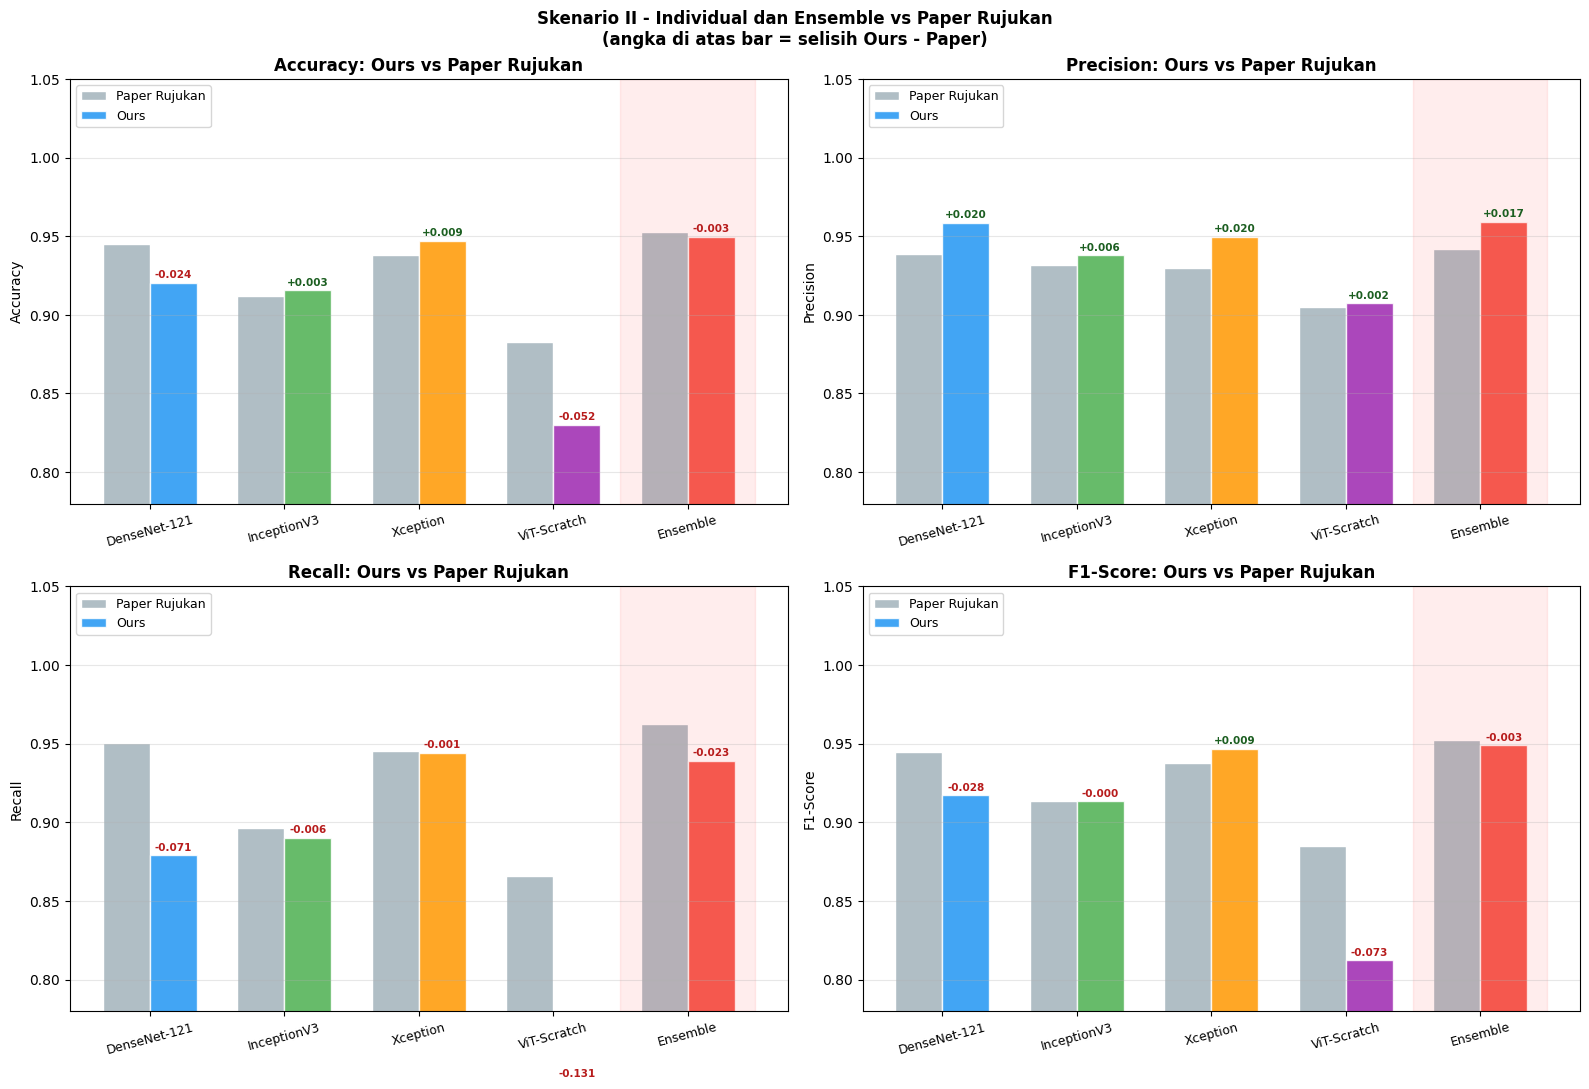

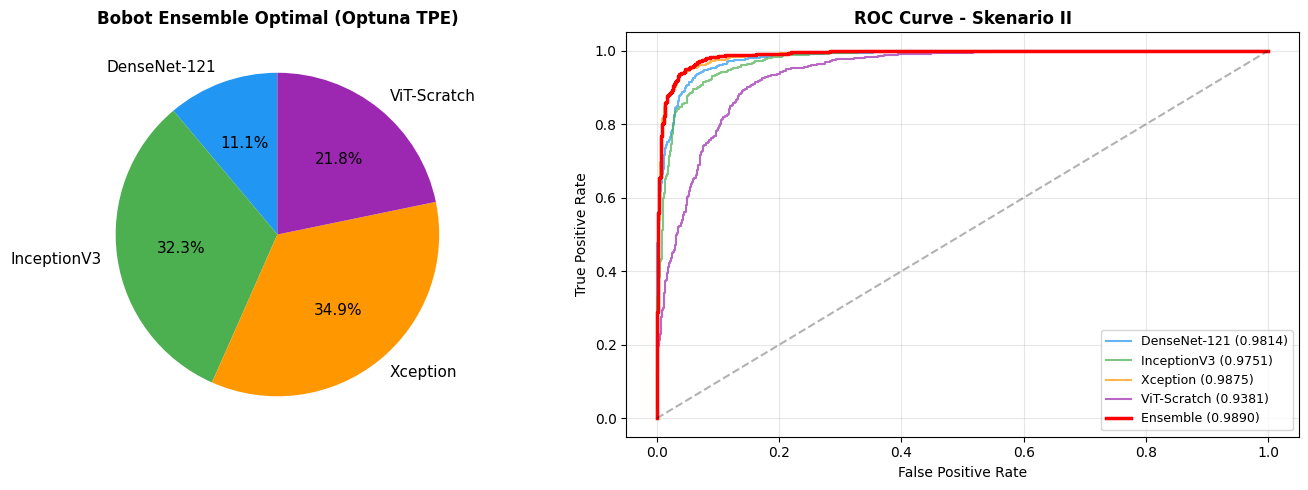

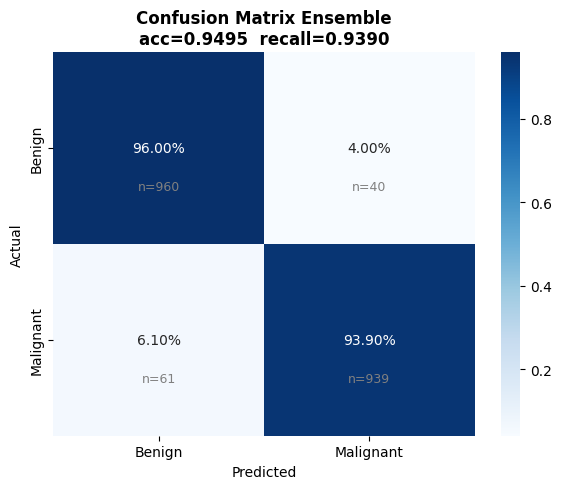

In [13]:
ens_probs   = ensemble_predict(
    all_probs_ds1, best_weights, MODEL_KEYS)
ens_metrics = compute_metrics(ds1_labels, ens_probs)
pens        = PAPER_REF['Ensemble']

print('=' * 65)
print('  Skenario II - Ensemble vs Paper Rujukan (DS1, TTA x8)')
print('=' * 65)
print(f'{"Model":<16} {"Acc":>8} {"Prec":>8} '
      f'{"Rec":>8} {"F1":>8} {"AUC":>8}')
print('-' * 58)
for arch_name in MODEL_KEYS:
    m = all_metrics_ds1[arch_name]
    print(f'{MODEL_LABELS[arch_name]:<16} '
          f'{m["accuracy"]:>8.4f} {m["precision"]:>8.4f} '
          f'{m["recall"]:>8.4f} {m["f1"]:>8.4f} '
          f'{m["auc"]:>8.4f}')
print('-' * 58)
print(f'{"Ensemble (ours)":<16} '
      f'{ens_metrics["accuracy"]:>8.4f} '
      f'{ens_metrics["precision"]:>8.4f} '
      f'{ens_metrics["recall"]:>8.4f} '
      f'{ens_metrics["f1"]:>8.4f} '
      f'{ens_metrics["auc"]:>8.4f}')
print(f'{"Paper Target":<16} '
      f'{pens["accuracy"]:>8.4f} '
      f'{pens["precision"]:>8.4f} '
      f'{pens["recall"]:>8.4f} '
      f'{pens["f1"]:>8.4f}')
print('=' * 58)
print('\nDelta Ours vs Paper:')
for k in ['accuracy', 'precision', 'recall', 'f1']:
    d    = ens_metrics[k] - pens[k]
    sign = 'OK' if d >= 0 else 'KURANG'
    print(f'  {k:<12}: {d:>+.4f}  {sign}')

# Visualisasi 1 - Grouped bar chart vs paper
colors      = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
plot_labels = [MODEL_LABELS[k] for k in MODEL_KEYS] + ['Ensemble']
metrics_p   = ['accuracy', 'precision', 'recall', 'f1']
m_labels    = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, metric, mlabel in zip(axes.flat, metrics_p, m_labels):
    ours  = [all_metrics_ds1[k][metric] for k in MODEL_KEYS]
    ours.append(ens_metrics[metric])
    paper = [PAPER_REF[MODEL_LABELS[k]][metric] for k in MODEL_KEYS]
    paper.append(pens[metric])

    x = np.arange(len(plot_labels))
    w = 0.35
    ax.bar(x - w/2, paper, w, label='Paper Rujukan',
           color='#B0BEC5', ec='white')
    b2 = ax.bar(x + w/2, ours, w, label='Ours',
                color=colors[:len(ours)], ec='white', alpha=0.85)
    for bar, pv, ov in zip(b2, paper, ours):
        d = ov - pv
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{d:+.3f}', ha='center', fontsize=7.5,
                color='#1B5E20' if d >= 0 else '#B71C1C',
                fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(plot_labels, rotation=15, fontsize=9)
    ax.set_ylabel(mlabel)
    ax.set_ylim([0.78, 1.05])
    ax.set_title(f'{mlabel}: Ours vs Paper Rujukan',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.axvspan(len(MODEL_KEYS) - 0.5, len(MODEL_KEYS) + 0.5,
               alpha=0.07, color='red')

plt.suptitle(
    'Skenario II - Individual dan Ensemble vs Paper Rujukan\n'
    '(angka di atas bar = selisih Ours - Paper)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'skenario2_vs_paper.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Visualisasi 2 - Pie bobot + ROC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.pie(
    best_weights,
    labels=[MODEL_LABELS[k] for k in MODEL_KEYS],
    autopct='%1.1f%%', colors=colors[:4],
    startangle=90, textprops={'fontsize': 11})
ax1.set_title('Bobot Ensemble Optimal (Optuna TPE)',
              fontweight='bold')

for arch_name, color in zip(MODEL_KEYS, colors):
    fpr, tpr, _ = roc_curve(
        ds1_labels, all_probs_ds1[arch_name])
    auc = all_metrics_ds1[arch_name]['auc']
    ax2.plot(fpr, tpr, color=color, lw=1.5, alpha=0.7,
             label=f'{MODEL_LABELS[arch_name]} ({auc:.4f})')
fpr_e, tpr_e, _ = roc_curve(ds1_labels, ens_probs)
ax2.plot(fpr_e, tpr_e, color='red', lw=2.5,
         label=f'Ensemble ({ens_metrics["auc"]:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve - Skenario II', fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'skenario2_pie_roc.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Visualisasi 3 - Confusion matrix ensemble
fig, ax = plt.subplots(figsize=(6, 5))
cm = np.array(ens_metrics['conf_mat'])
sns.heatmap(
    cm.astype(float) / cm.sum(axis=1, keepdims=True),
    annot=True, fmt='.2%', cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES, ax=ax)
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                ha='center', fontsize=9, color='gray')
ax.set_title(
    f'Confusion Matrix Ensemble\n'
    f'acc={ens_metrics["accuracy"]:.4f}  '
    f'recall={ens_metrics["recall"]:.4f}',
    fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'skenario2_confmat.png',
            dpi=150, bbox_inches='tight')
plt.show()

with open(OUTPUT_DIR / 'skenario2_ensemble.json', 'w') as f:
    json.dump({
        'ensemble'   : {k: v for k, v in ens_metrics.items()
                        if k != 'conf_mat'},
        'individual' : {
            k: {kk: vv
                for kk, vv in all_metrics_ds1[k].items()
                if kk != 'conf_mat'}
            for k in MODEL_KEYS},
        'paper_ref'  : PAPER_REF,
        'weights'    : weights_dict,
    }, f, indent=2)


---
# Skenario III - Cross-Dataset Generalisasi (DS2 Mendeley)
Evaluasi model tanpa retrain pada dataset yang tidak digunakan saat training.


## 13. Evaluasi DS2 dan Perbandingan Cross-Dataset


Evaluasi DS2 (TTA x8)...
  DenseNet-121   ... acc=0.9210  recall=0.8860  auc=0.9830
  InceptionV3    ... acc=0.9160  recall=0.8880  auc=0.9754
  Xception       ... acc=0.9550  recall=0.9480  auc=0.9861
  ViT-Scratch    ... acc=0.8890  recall=0.8720  auc=0.9555

  Skenario III - DS1 vs DS2 vs Paper Rujukan
Model              DS1 Acc   DS2 Acc     Drop   DS1 Rec   DS2 Rec    Paper    Delta
----------------------------------------------------------------------------------
DenseNet-121        0.9205    0.9210  -0.0005    0.8790    0.8860   0.9450  -0.0245
InceptionV3         0.9155    0.9160  -0.0005    0.8900    0.8880   0.9120  +0.0035
Xception            0.9470    0.9550  -0.0080    0.9440    0.9480   0.9380  +0.0090
ViT-Scratch         0.8300    0.8890  -0.0590    0.7350    0.8720   0.8825  -0.0525
----------------------------------------------------------------------------------
Ensemble            0.9495    0.9430  +0.0065    0.9390    0.9260   0.9525  -0.0030


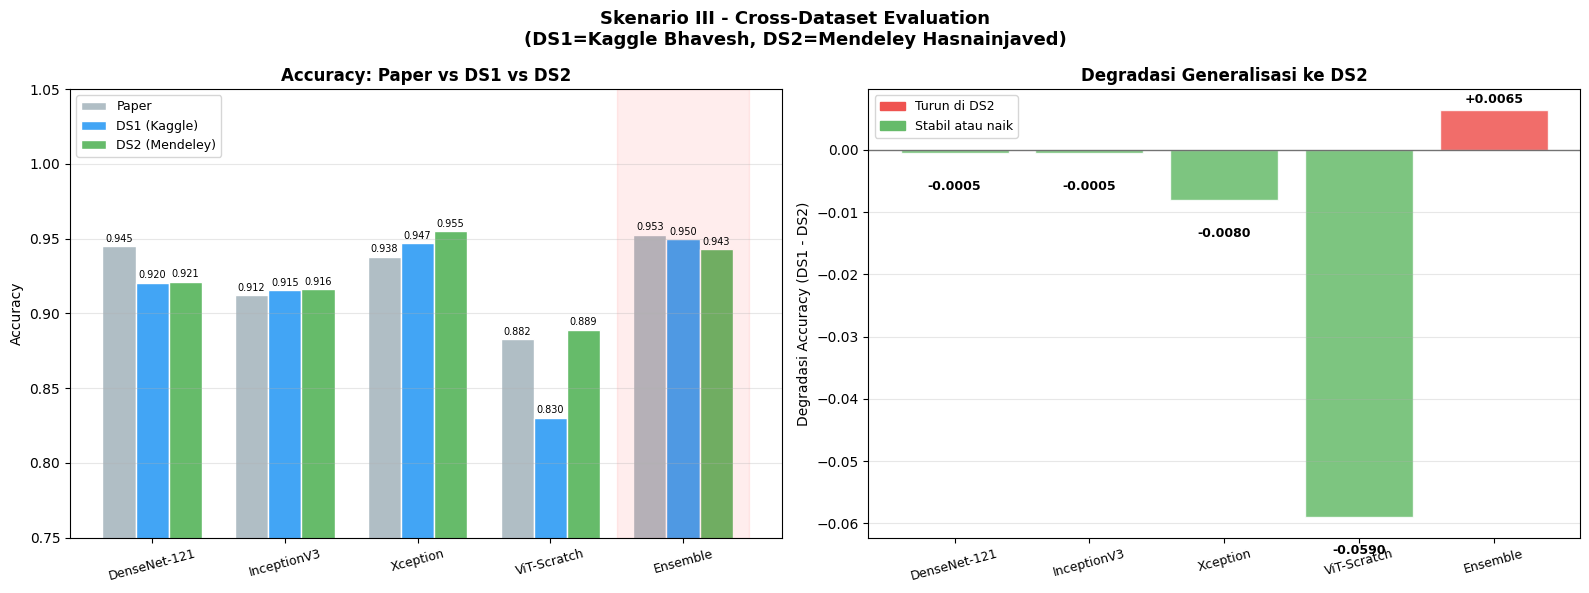

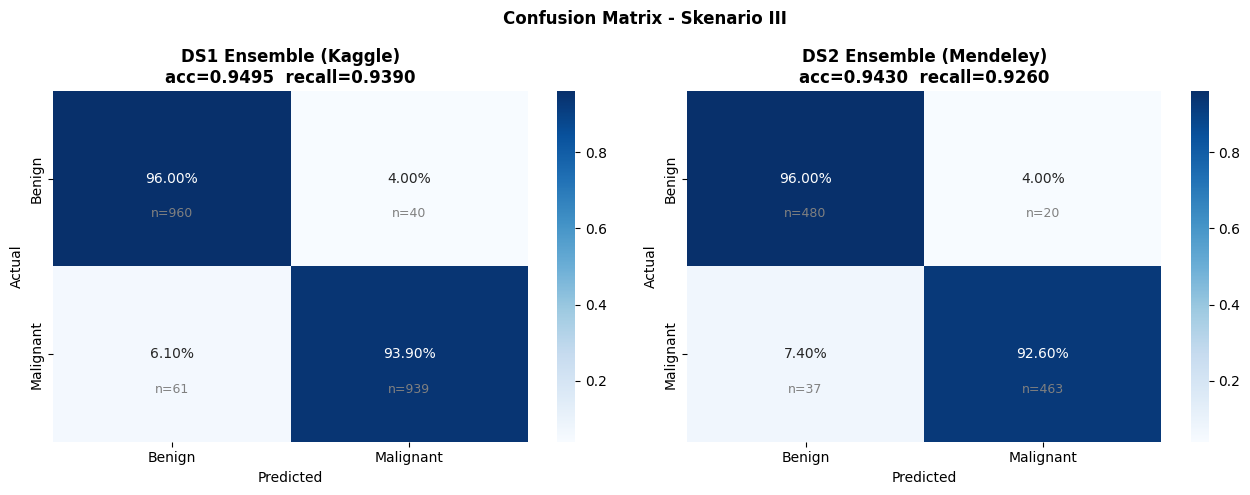

In [14]:
print('Evaluasi DS2 (TTA x8)...')
ds2_probs  = {}
ds2_labels = None

for arch_name, model in all_models.items():
    img_sz = (VIT_IMG_SIZE if arch_name == 'vit_scratch'
              else ARCH_CONFIGS[arch_name]['img_size'])
    print(f'  {MODEL_LABELS[arch_name]:<15}...', end=' ')
    try:
        lbs, prbs = get_probs(model, DS2_TEST, img_sz, TTA_STEPS)
        ds2_probs[arch_name] = prbs
        if ds2_labels is None:
            ds2_labels = lbs
        m = compute_metrics(lbs, prbs)
        print(f'acc={m["accuracy"]:.4f}  '
              f'recall={m["recall"]:.4f}  '
              f'auc={m["auc"]:.4f}')
    except Exception as e:
        print(f'ERROR: {e}')

ens_probs_ds2   = ensemble_predict(
    ds2_probs, best_weights, MODEL_KEYS)
ens_metrics_ds2 = compute_metrics(ds2_labels, ens_probs_ds2)
s3_metrics      = {
    k: compute_metrics(ds2_labels, ds2_probs[k])
    for k in MODEL_KEYS if k in ds2_probs}

print()
print('=' * 82)
print('  Skenario III - DS1 vs DS2 vs Paper Rujukan')
print('=' * 82)
print(f'{"Model":<16} {"DS1 Acc":>9} {"DS2 Acc":>9} '
      f'{"Drop":>8} {"DS1 Rec":>9} {"DS2 Rec":>9} '
      f'{"Paper":>8} {"Delta":>8}')
print('-' * 82)

for arch_name in MODEL_KEYS:
    if arch_name not in s3_metrics:
        continue
    label = MODEL_LABELS[arch_name]
    m1    = all_metrics_ds1[arch_name]
    m2    = s3_metrics[arch_name]
    p     = PAPER_REF[label]
    print(f'{label:<16} '
          f'{m1["accuracy"]:>9.4f} '
          f'{m2["accuracy"]:>9.4f} '
          f'{m1["accuracy"]-m2["accuracy"]:>+8.4f} '
          f'{m1["recall"]:>9.4f} '
          f'{m2["recall"]:>9.4f} '
          f'{p["accuracy"]:>8.4f} '
          f'{m1["accuracy"]-p["accuracy"]:>+8.4f}')

print('-' * 82)
print(f'{"Ensemble":<16} '
      f'{ens_metrics["accuracy"]:>9.4f} '
      f'{ens_metrics_ds2["accuracy"]:>9.4f} '
      f'{ens_metrics["accuracy"]-ens_metrics_ds2["accuracy"]:>+8.4f} '
      f'{ens_metrics["recall"]:>9.4f} '
      f'{ens_metrics_ds2["recall"]:>9.4f} '
      f'{pens["accuracy"]:>8.4f} '
      f'{ens_metrics["accuracy"]-pens["accuracy"]:>+8.4f}')
print('=' * 82)

# Visualisasi 1 - Bar chart DS1 vs DS2 vs Paper
valid_keys  = [k for k in MODEL_KEYS if k in s3_metrics]
plot_lbs3   = [MODEL_LABELS[k] for k in valid_keys] + ['Ensemble']
paper_accs  = [PAPER_REF[MODEL_LABELS[k]]['accuracy']
               for k in valid_keys]
paper_accs.append(pens['accuracy'])
ds1_accs    = [all_metrics_ds1[k]['accuracy'] for k in valid_keys]
ds1_accs.append(ens_metrics['accuracy'])
ds2_accs    = [s3_metrics[k]['accuracy'] for k in valid_keys]
ds2_accs.append(ens_metrics_ds2['accuracy'])

x = np.arange(len(plot_lbs3))
w = 0.25
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.bar(x - w, paper_accs, w, label='Paper',
       color='#B0BEC5', ec='white')
ax.bar(x,     ds1_accs,   w, label='DS1 (Kaggle)',
       color='#42A5F5', ec='white')
ax.bar(x + w, ds2_accs,   w, label='DS2 (Mendeley)',
       color='#66BB6A', ec='white')
for bars_c in ax.containers:
    for bar in bars_c:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(plot_lbs3, rotation=15, fontsize=9)
ax.set_ylim([0.75, 1.05])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Paper vs DS1 vs DS2', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.axvspan(len(valid_keys) - 0.5, len(valid_keys) + 0.5,
           alpha=0.07, color='red')

ax = axes[1]
drops  = [d1 - d2 for d1, d2 in zip(ds1_accs, ds2_accs)]
bc     = ['#EF5350' if d > 0 else '#66BB6A' for d in drops]
bars   = ax.bar(plot_lbs3, drops, color=bc, ec='white', alpha=0.85)
for bar, val in zip(bars, drops):
    yp = (bar.get_height() + 0.001
          if val >= 0 else bar.get_height() - 0.006)
    ax.text(bar.get_x() + bar.get_width() / 2, yp,
            f'{val:+.4f}', ha='center', fontsize=9,
            fontweight='bold')
ax.axhline(0, color='black', lw=1, alpha=0.5)
ax.set_ylabel('Degradasi Accuracy (DS1 - DS2)')
ax.set_title('Degradasi Generalisasi ke DS2', fontweight='bold')
ax.set_xticklabels(plot_lbs3, rotation=15, fontsize=9)
ax.grid(axis='y', alpha=0.3)
p1 = mpatches.Patch(color='#EF5350', label='Turun di DS2')
p2 = mpatches.Patch(color='#66BB6A', label='Stabil atau naik')
ax.legend(handles=[p1, p2], fontsize=9)

plt.suptitle(
    'Skenario III - Cross-Dataset Evaluation\n'
    '(DS1=Kaggle Bhavesh, DS2=Mendeley Hasnainjaved)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'skenario3_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Visualisasi 2 - Confusion matrix DS1 vs DS2
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (title, ds_m) in zip(axes, [
    ('DS1 Ensemble (Kaggle)',   ens_metrics),
    ('DS2 Ensemble (Mendeley)', ens_metrics_ds2),
]):
    cm = np.array(ds_m['conf_mat'])
    sns.heatmap(
        cm.astype(float) / cm.sum(axis=1, keepdims=True),
        annot=True, fmt='.2%', cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES, ax=ax)
    for i in range(2):
        for j in range(2):
            ax.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                    ha='center', fontsize=9, color='gray')
    ax.set_title(
        f'{title}\n'
        f'acc={ds_m["accuracy"]:.4f}  '
        f'recall={ds_m["recall"]:.4f}',
        fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix - Skenario III',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'skenario3_confmat.png',
            dpi=150, bbox_inches='tight')
plt.show()

with open(OUTPUT_DIR / 'skenario3_cross.json', 'w') as f:
    json.dump({
        'ds1_ensemble' : {k: v for k, v in ens_metrics.items()
                          if k != 'conf_mat'},
        'ds2_ensemble' : {k: v for k, v in ens_metrics_ds2.items()
                          if k != 'conf_mat'},
        'paper_ref'    : PAPER_REF,
    }, f, indent=2)


## 14. Ringkasan Akhir Semua Skenario


In [15]:
print('=' * 78)
print('  Ringkasan Akhir - Skenario I + II + III vs Paper Rujukan')
print('=' * 78)

rows = []
for arch_name in MODEL_KEYS:
    label = MODEL_LABELS[arch_name]
    m1    = all_metrics_ds1[arch_name]
    m3    = s3_metrics.get(arch_name, {})
    paper = PAPER_REF[label]
    bp    = tpe_best_params.get(arch_name, {})
    rows.append({
        'Model'          : label,
        'Paper Acc'      : f"{paper['accuracy']:.4f}",
        'Ours DS1'       : f"{m1['accuracy']:.4f}",
        'Ours DS2'       : f"{m3.get('accuracy', 0):.4f}",
        'Paper Recall'   : f"{paper['recall']:.4f}",
        'Ours Recall'    : f"{m1['recall']:.4f}",
        'AUC'            : f"{m1['auc']:.4f}",
        'Best LR'        : f"{bp.get('lr', 0):.2e}",
        'Best Optimizer' : bp.get('optimizer_name', ''),
        'Delta Acc'      : f"{m1['accuracy'] - paper['accuracy']:+.4f}",
    })

rows.append({
    'Model'          : 'ENSEMBLE',
    'Paper Acc'      : f"{pens['accuracy']:.4f}",
    'Ours DS1'       : f"{ens_metrics['accuracy']:.4f}",
    'Ours DS2'       : f"{ens_metrics_ds2['accuracy']:.4f}",
    'Paper Recall'   : f"{pens['recall']:.4f}",
    'Ours Recall'    : f"{ens_metrics['recall']:.4f}",
    'AUC'            : f"{ens_metrics['auc']:.4f}",
    'Best LR'        : '-',
    'Best Optimizer' : '-',
    'Delta Acc'      :
        f"{ens_metrics['accuracy'] - pens['accuracy']:+.4f}",
})

df_final = pd.DataFrame(rows)
display(df_final)
df_final.to_csv(OUTPUT_DIR / 'ringkasan_akhir.csv', index=False)

delta = ens_metrics['accuracy'] - pens['accuracy']
print(f'\nEnsemble DS1 : '
      f'acc={ens_metrics["accuracy"]:.4f}  '
      f'recall={ens_metrics["recall"]:.4f}  '
      f'AUC={ens_metrics["auc"]:.4f}')
print(f'Ensemble DS2 : '
      f'acc={ens_metrics_ds2["accuracy"]:.4f}  '
      f'recall={ens_metrics_ds2["recall"]:.4f}')
print(f'Paper target : '
      f'acc={pens["accuracy"]:.4f}  '
      f'recall={pens["recall"]:.4f}')
print(f'Delta vs paper: {delta:+.4f}  '
      f'{"Melampaui target" if delta >= 0 else "Belum mencapai target"}')

print(f'\nOutput tersimpan di: {OUTPUT_DIR}')
for fp in sorted(OUTPUT_DIR.rglob('*')):
    if fp.is_file():
        print(f'  {str(fp.relative_to(OUTPUT_DIR)):<50} '
              f'({fp.stat().st_size / 1024:.1f} KB)')


  Ringkasan Akhir - Skenario I + II + III vs Paper Rujukan


,Model,Paper Acc,Ours DS1,Ours DS2,Paper Recall,Ours Recall,AUC,Best LR,Best Optimizer,Delta Acc
0,DenseNet-121,0.9450,0.9205,0.9210,0.9504,0.8790,0.9814,3.05e-03,adamw,-0.0245
1,InceptionV3,0.9120,0.9155,0.9160,0.8962,0.8900,0.9751,4.26e-03,adam,+0.0035
2,Xception,0.9380,0.9470,0.9550,0.9451,0.9440,0.9875,1.80e-03,adamw,+0.0090
3,ViT-Scratch,0.8825,0.8300,0.8890,0.8660,0.7350,0.9381,7.22e-04,adamw,-0.0525
4,ENSEMBLE,0.9525,0.9495,0.9430,0.9622,0.9390,0.9890,-,-,-0.0030



Ensemble DS1 : acc=0.9495  recall=0.9390  AUC=0.9890
Ensemble DS2 : acc=0.9430  recall=0.9260
Paper target : acc=0.9525  recall=0.9622
Delta vs paper: -0.0030  Belum mencapai target

Output tersimpan di: /kaggle/working/full_pipeline_results
  all_best_params.json                               (1.4 KB)
  checkpoints/densenet121_best.pth                   (27780.7 KB)
  checkpoints/inception_v3_best.pth                  (85460.9 KB)
  checkpoints/vit_scratch_best.pth                   (335103.6 KB)
  checkpoints/xception_best.pth                      (81599.7 KB)
  ensemble_weights.json                              (0.1 KB)
  ringkasan_akhir.csv                                (0.5 KB)
  skenario1_vs_paper.csv                             (0.3 KB)
  skenario2_confmat.png                              (44.6 KB)
  skenario2_ensemble.json                            (1.7 KB)
  skenario2_pie_roc.png                              (118.0 KB)
  skenario2_vs_paper.png                             (1